Installation

In [1]:
import os, re
import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
!pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
!pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2
!pip install jiwer
!pip install einops addict easydict

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 19.9 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.7/69.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.9/122.9 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.5/376.5 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.5/540.5 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

Unsloth

In [2]:
from huggingface_hub import snapshot_download
snapshot_download("unsloth/DeepSeek-OCR-2", local_dir = "deepseek_ocr2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

conversation.py: 0.00B [00:00, ?B/s]

LICENSE.txt: 0.00B [00:00, ?B/s]

configuration_deepseek_v2.py: 0.00B [00:00, ?B/s]

...

modeling_deepseekv2.py: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

processor_config.json:   0%|          | 0.00/460 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

'/content/deepseek_ocr2'

In [3]:
from unsloth import FastVisionModel # FastLanguageModel for LLMs
import torch
from transformers import AutoModel
import os

model, tokenizer = FastVisionModel.from_pretrained(
    "./deepseek_ocr2",
    load_in_4bit = True,
    auto_model = AutoModel,
    trust_remote_code = True,
    unsloth_force_compile = True,
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR2. This is not supported for all configurations of models and can yield errors.


Unsloth: WARNING `trust_remote_code` is True.
Are you certain you want to do remote code execution?
==((====))==  Unsloth 2026.2.1: Fast Deepseekocr2 patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.33.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR2. This is not supported for all configurations of models and can yield errors.


Dataset and Show Example of Dataset

In [4]:
from datasets import load_dataset
baseline_dataset = load_dataset("Teklia/IAM-line", split = "test[:500]")

README.md: 0.00B [00:00, ?B/s]

data/train.parquet:   0%|          | 0.00/167M [00:00<?, ?B/s]

data/validation.parquet:   0%|          | 0.00/24.7M [00:00<?, ?B/s]

data/test.parquet:   0%|          | 0.00/73.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6482 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/976 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2915 [00:00<?, ? examples/s]

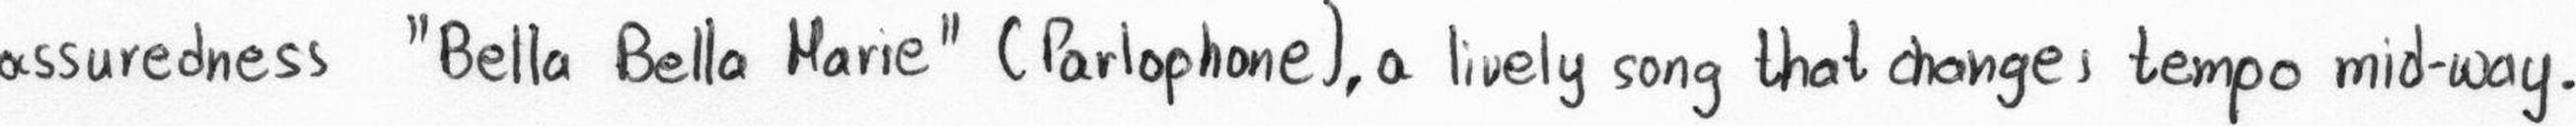

In [5]:
sample = baseline_dataset[0]

sample["image"].save("temp.jpg")
sample["image"]

In [6]:
ground_truth = sample["text"]

print("GT:", ground_truth)


GT: assuredness " Bella Bella Marie " ( Parlophone ) , a lively song that changes tempo mid-way .


# Evaluate Deepseek OCR before Fine Tuning

In [7]:
from jiwer import cer, wer
import os

baseline_total_cer = 0
baseline_total_wer = 0

for i, sample in enumerate(baseline_dataset):

    if os.path.exists("result.mmd"):
        os.remove("result.mmd")

    # Simpan image sementara
    sample["image"].save("temp.jpg")
    gt = sample["text"].strip()

    # Jalankan OCR
    model.infer(
        tokenizer,
        prompt = "<image>\nRead the handwritten text. Output plain text only.",
        image_file="temp.jpg",
        output_path=".",
        base_size=1024,
        image_size=768,
        crop_mode=False,
        save_results=True,
        test_compress=False
    )

    # Ambil hasil OCR dari file
    with open("result.mmd", "r") as f:
        pred = f.read().strip()

    # Hitung metric
    baseline_total_cer += cer(gt, pred)
    baseline_total_wer += wer(gt, pred)

    print(f"Done {i+1}/{len(baseline_dataset)}\n\n")

print("\n=== BASELINE RESULT ===")
print("Baseline CER:", baseline_total_cer / len(baseline_dataset))
print("Baseline WER:", baseline_total_wer / len(baseline_dataset))

directly resize


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.



===============save results:===============


image: 0it [00:00, ?it/s]
other: 0it [00:00, ?it/s]

Done 1/500


directly resize


...

image: 0it [00:00, ?it/s]
other: 0it [00:00, ?it/s]

Done 499/500


directly resize



===============save results:===============


image: 0it [00:00, ?it/s]
other: 0it [00:00, ?it/s]

Done 500/500



=== BASELINE RESULT ===
Baseline CER: 1.8149106057969022
Baseline WER: 1.8323266733266734


# Fine Tuning Process

In [8]:
model = FastVisionModel.get_peft_model(
    model,
    target_modules = [
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],

    r = 16,           # The larger, the higher the accuracy, but might overfit
    lora_alpha = 16,  # Recommended alpha == r at least
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
    # target_modules = "all-linear", # Optional now! Can specify a list if needed
)

Unsloth: Detected MoE model with num_experts = 64 and target_modules = ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']. Enabling LoRA on MoE parameters: ['mlp.experts.gate_up_proj', 'mlp.experts.down_proj']
Unsloth: PEFT set target_parameters but found no matching parameters.
This is expected for MoE models - Unsloth handles MoE expert LoRA targeting separately.
Unsloth: Making `model.base_model.model.model` require gradients


In [9]:
instruction = "<image>\nRead the handwritten text. Output plain text only."

def convert_to_conversation(sample):
    """Convert dataset sample to conversation format"""
    conversation = [
        {
            "role": "user",  # ← UBAH INI (hapus pipe, lowercase)
            "content": instruction,
            "images": [sample['image']]
        },
        {
            "role": "assistant",  # ← UBAH INI (hapus pipe, lowercase)
            "content": sample["text"]
        },
    ]
    return {"messages": conversation}

# Load dataset
train_dataset = load_dataset("Teklia/IAM-line", split="train[:2000]")
converted_dataset = train_dataset.map(convert_to_conversation, remove_columns=train_dataset.column_names)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [10]:
# DeepSeek OCR2 Data Collator - Fixed Version

import torch
import math
from dataclasses import dataclass
from typing import Dict, List, Any, Tuple
from PIL import Image, ImageOps
from torch.nn.utils.rnn import pad_sequence
import io

from deepseek_ocr2.modeling_deepseekocr2 import (
    format_messages,
    text_encode,
    BasicImageTransform,
    dynamic_preprocess,
)

@dataclass
class DeepSeekOCR2DataCollator:
    """
    Data Collator for DeepSeek OCR2 fine-tuning

    Args:
        tokenizer: Tokenizer
        model: Model
        image_size: Size for image patches (default: 768)
        base_size: Size for global view (default: 1024)
        crop_mode: Whether to use dynamic cropping for large images
        train_on_responses_only: If True, only train on assistant responses (mask user prompts)
    """
    tokenizer: Any
    model: Any
    image_size: int = 768
    base_size: int = 1024
    crop_mode: bool = True
    image_token_id: int = 128815
    train_on_responses_only: bool = True

    def __init__(
        self,
        tokenizer,
        model,
        image_size: int = 768,
        base_size: int = 1024,
        crop_mode: bool = True,
        train_on_responses_only: bool = True,
    ):
        self.tokenizer = tokenizer
        self.model = model
        self.image_size = image_size
        self.base_size = base_size
        self.crop_mode = crop_mode
        self.image_token_id = 128815
        self.dtype = model.dtype  # Get dtype from model
        self.train_on_responses_only = train_on_responses_only

        self.image_transform = BasicImageTransform(
            mean = (0.5, 0.5, 0.5),
            std = (0.5, 0.5, 0.5),
            normalize = True
        )
        self.patch_size = 16
        self.downsample_ratio = 4

        # Get BOS token ID from tokenizer
        if hasattr(tokenizer, 'bos_token_id') and tokenizer.bos_token_id is not None:
            self.bos_id = tokenizer.bos_token_id
        else:
            self.bos_id = 0
            print(f"Warning: tokenizer has no bos_token_id, using default: {self.bos_id}")

    def deserialize_image(self, image_data) -> Image.Image:
        """Convert image data (bytes dict or PIL Image) to PIL Image in RGB mode"""
        if isinstance(image_data, Image.Image):
            return image_data.convert("RGB")
        elif isinstance(image_data, dict) and 'bytes' in image_data:
            image_bytes = image_data['bytes']
            image = Image.open(io.BytesIO(image_bytes))
            return image.convert("RGB")
        else:
            raise ValueError(f"Unsupported image format: {type(image_data)}")

    def calculate_image_token_count(self, image: Image.Image, crop_ratio: Tuple[int, int]) -> int:
        """Calculate the number of tokens this image will generate"""
        num_queries = math.ceil((self.image_size // self.patch_size) / self.downsample_ratio)
        num_queries_base = math.ceil((self.base_size // self.patch_size) / self.downsample_ratio)

        width_crop_num, height_crop_num = crop_ratio

        if self.crop_mode:
            img_tokens = num_queries_base * num_queries_base + 1
            if width_crop_num > 1 or height_crop_num > 1:
                img_tokens += (num_queries * width_crop_num) * (num_queries * height_crop_num)
        else:
            img_tokens = num_queries * num_queries + 1

        return img_tokens

    def process_image(self, image: Image.Image) -> Tuple[List, List, List, List, Tuple[int, int]]:
        """
        Process a single image based on crop_mode and size thresholds

        Returns:
            Tuple of (images_list, images_crop_list, images_spatial_crop, tokenized_image, crop_ratio)
        """
        images_list = []
        images_crop_list = []
        images_spatial_crop = []

        if self.crop_mode:
            # Determine crop ratio based on image size
            if image.size[0] <= 768 and image.size[1] <= 768:
                crop_ratio = (1, 1)
                images_crop_raw = []
            else:
                images_crop_raw, crop_ratio = dynamic_preprocess(
                    image, min_num = 2, max_num = 6,
                    image_size = self.image_size, use_thumbnail = False
                )

            # Process global view with padding
            global_view = ImageOps.pad(
                image, (self.base_size, self.base_size),
                color = tuple(int(x * 255) for x in self.image_transform.mean)
            )
            images_list.append(self.image_transform(global_view).to(self.dtype))

            width_crop_num, height_crop_num = crop_ratio
            images_spatial_crop.append([width_crop_num, height_crop_num])

            # Process local views (crops) if applicable
            if width_crop_num > 1 or height_crop_num > 1:
                for crop_img in images_crop_raw:
                    images_crop_list.append(
                        self.image_transform(crop_img).to(self.dtype)
                    )

            # Calculate image tokens
            num_queries = math.ceil((self.image_size // self.patch_size) / self.downsample_ratio)
            num_queries_base = math.ceil((self.base_size // self.patch_size) / self.downsample_ratio)

            tokenized_image = ([self.image_token_id] * num_queries_base) * num_queries_base
            tokenized_image += [self.image_token_id]

            if width_crop_num > 1 or height_crop_num > 1:
                tokenized_image += ([self.image_token_id] * (num_queries * width_crop_num)) * (
                    num_queries * height_crop_num)

        else:  # crop_mode = False
            crop_ratio = (1, 1)
            images_spatial_crop.append([1, 1])

            # For smaller base sizes, resize; for larger, pad
            if self.base_size <= 768:
                resized_image = image.resize((self.base_size, self.base_size), Image.LANCZOS)
                images_list.append(self.image_transform(resized_image).to(self.dtype))
            else:
                global_view = ImageOps.pad(
                    image, (self.base_size, self.base_size),
                    color = tuple(int(x * 255) for x in self.image_transform.mean)
                )
                images_list.append(self.image_transform(global_view).to(self.dtype))

            num_queries = math.ceil((self.base_size // self.patch_size) / self.downsample_ratio)
            tokenized_image = ([self.image_token_id] * num_queries) * num_queries
            tokenized_image += [self.image_token_id]

        return images_list, images_crop_list, images_spatial_crop, tokenized_image, crop_ratio

    def process_single_sample(self, messages: List[Dict]) -> Dict[str, Any]:
        """
        Process a single conversation into model inputs.
        """

        # --- 1. Setup ---
        images = []
        for message in messages:
            if "images" in message and message["images"]:
                for img_data in message["images"]:
                    if img_data is not None:
                        pil_image = self.deserialize_image(img_data)
                        images.append(pil_image)

        if not images:
            raise ValueError("No images found in sample. Please ensure all samples contain images.")

        tokenized_str = []
        images_seq_mask = []
        images_list, images_crop_list, images_spatial_crop = [], [], []

        prompt_token_count = -1  # Index to start training
        assistant_started = False
        image_idx = 0

        # Add BOS token at the very beginning
        tokenized_str.append(self.bos_id)
        images_seq_mask.append(False)

        for message in messages:
            role = message["role"]
            content = message["content"]

            # FIXED: Support multiple role formats
            # Normalize role to lowercase and handle both formats
            role_normalized = role.lower().replace("<|", "").replace("|>", "").strip()

            # Check if this is the assistant's turn
            if role_normalized == "assistant":
                if not assistant_started:
                    # This is the split point. All tokens added *so far*
                    # are part of the prompt.
                    prompt_token_count = len(tokenized_str)
                    assistant_started = True

                # Append the EOS token string to the *end* of assistant content
                content = f"{content.strip()} {self.tokenizer.eos_token}"

            # Split this message's content by the image token
            text_splits = content.split('<image>')

            for i, text_sep in enumerate(text_splits):
                # Tokenize the text part
                tokenized_sep = text_encode(self.tokenizer, text_sep, bos = False, eos = False)
                tokenized_str.extend(tokenized_sep)
                images_seq_mask.extend([False] * len(tokenized_sep))

                # If this text is followed by an <image> tag
                if i < len(text_splits) - 1:
                    if image_idx >= len(images):
                        raise ValueError(
                            f"Data mismatch: Found '<image>' token but no corresponding image."
                        )

                    # Process the image
                    image = images[image_idx]
                    img_list, crop_list, spatial_crop, tok_img, _ = self.process_image(image)

                    images_list.extend(img_list)
                    images_crop_list.extend(crop_list)
                    images_spatial_crop.extend(spatial_crop)

                    # Add image placeholder tokens
                    tokenized_str.extend(tok_img)
                    images_seq_mask.extend([True] * len(tok_img))

                    image_idx += 1  # Move to the next image

        # --- 3. Validation and Final Prep ---
        if image_idx != len(images):
            raise ValueError(
                f"Data mismatch: Found {len(images)} images but only {image_idx} '<image>' tokens were used."
            )

        # If we never found an assistant message, we're in a weird state
        # (e.g., user-only prompt). We mask everything.
        if not assistant_started:
            print("Warning: No assistant message found in sample. Masking all tokens.")
            prompt_token_count = len(tokenized_str)

        # Prepare image tensors
        images_ori = torch.stack(images_list, dim = 0)
        images_spatial_crop_tensor = torch.tensor(images_spatial_crop, dtype = torch.long)

        if images_crop_list:
            images_crop = torch.stack(images_crop_list, dim = 0)
        else:
            images_crop = torch.zeros((1, 3, self.base_size, self.base_size), dtype = self.dtype)

        return {
            "input_ids": torch.tensor(tokenized_str, dtype = torch.long),
            "images_seq_mask": torch.tensor(images_seq_mask, dtype = torch.bool),
            "images_ori": images_ori,
            "images_crop": images_crop,
            "images_spatial_crop": images_spatial_crop_tensor,
            "prompt_token_count": prompt_token_count,
        }

    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        """Collate batch of samples"""
        batch_data = []

        # Process each sample
        for feature in features:
            try:
                processed = self.process_single_sample(feature['messages'])
                batch_data.append(processed)
            except Exception as e:
                print(f"Error processing sample: {e}")
                continue

        if not batch_data:
            raise ValueError("No valid samples in batch")

        # Extract lists
        input_ids_list = [item['input_ids'] for item in batch_data]
        images_seq_mask_list = [item['images_seq_mask'] for item in batch_data]
        prompt_token_counts = [item['prompt_token_count'] for item in batch_data]

        # Pad sequences
        input_ids = pad_sequence(input_ids_list, batch_first = True, padding_value = self.tokenizer.pad_token_id)
        images_seq_mask = pad_sequence(images_seq_mask_list, batch_first = True, padding_value = False)

        # Create labels
        labels = input_ids.clone()

        # Mask padding tokens
        labels[labels == self.tokenizer.pad_token_id] = -100

        # Mask image tokens (model shouldn't predict these)
        labels[images_seq_mask] = -100

        # Mask user prompt tokens when train_on_responses_only = True (only train on assistant responses)
        if self.train_on_responses_only:
            for idx, prompt_count in enumerate(prompt_token_counts):
                if prompt_count > 0:
                    labels[idx, :prompt_count] = -100

        # Create attention mask
        attention_mask = (input_ids != self.tokenizer.pad_token_id).long()

        # Prepare images batch (list of tuples)
        images_batch = []
        for item in batch_data:
            images_batch.append((item['images_crop'], item['images_ori']))

        # Stack spatial crop info
        images_spatial_crop = torch.cat([item['images_spatial_crop'] for item in batch_data], dim = 0)

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels,
            "images": images_batch,
            "images_seq_mask": images_seq_mask,
            "images_spatial_crop": images_spatial_crop,
        }


In [11]:
from transformers import Trainer, TrainingArguments
from unsloth import is_bf16_supported
FastVisionModel.for_training(model) # Enable for training!
data_collator = DeepSeekOCR2DataCollator(
    tokenizer = tokenizer,
    model = model,
    image_size = 768,
    base_size = 1024,
    crop_mode = False,
    train_on_responses_only = True,
)
trainer = Trainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = data_collator, # Must use!
    train_dataset = converted_dataset,
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        # max_steps = 60, #harusnya 60, ini coba biar cepet dulu
        num_train_epochs = 1, # Set this instead of max_steps for full training runs
        learning_rate = 2e-4,
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.001,
        lr_scheduler_type = "linear",
        seed = 3407,
        fp16 = not is_bf16_supported(),  # Use fp16 if bf16 is not supported
        bf16 = is_bf16_supported(),  # Use bf16 if supported
        output_dir = "outputs",
        report_to = "none",     # For Weights and Biases
        dataloader_num_workers = 2,
        # You MUST put the below items for vision finetuning:
        remove_unused_columns = False,
    ),
)

/tmp/ipython-input-1512346099.py:12: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer._unsloth___init__`. Use `processing_class` instead.
  trainer = Trainer(


In [12]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = Tesla T4. Max memory = 14.563 GB.
4.264 GB of memory reserved.


In [13]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 2,000 | Num Epochs = 1 | Total steps = 250
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 86,307,840 of 3,475,427,200 (2.48% trained)
Unsloth: Not an error, but DeepseekOCR2ForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


Step,Training Loss
1,4.417300
2,3.921800
3,4.316100
4,3.895600
5,3.017400
6,2.359300
7,2.491400
8,1.840700


Step,Training Loss
1,4.417300
2,3.921800
3,4.316100
4,3.895600
5,3.017400
6,2.359300
7,2.491400
8,1.840700
9,1.846800
10,1.294800


You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR2. This is not supported for all configurations of models and can yield errors.


In [14]:
# @title Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

5534.7518 seconds used for training.
92.25 minutes used for training.
Peak reserved memory = 4.264 GB.
Peak reserved memory for training = 0.0 GB.
Peak reserved memory % of max memory = 29.28 %.
Peak reserved memory for training % of max memory = 0.0 %.


In [15]:
from jiwer import cer, wer
import os

test_dataset = load_dataset("Teklia/IAM-line", split="test[:500]")

finetuned_total_cer = 0
finetuned_total_wer = 0

for i, sample in enumerate(test_dataset):

    if os.path.exists("result.mmd"):
        os.remove("result.mmd")

    # Simpan image sementara
    sample["image"].save("temp.jpg")
    gt = sample["text"].strip()

    # Jalankan OCR
    model.infer(
        tokenizer,
        prompt = "<image>\nRead the handwritten text. Output plain text only.",
        image_file="temp.jpg",
        output_path=".",
        base_size=1024,
        image_size=768,
        crop_mode=False,
        save_results=True,
        test_compress=False
    )

    # Ambil hasil OCR dari file
    with open("result.mmd", "r") as f:
        pred = f.read().strip()

    # Hitung metric
    finetuned_total_cer += cer(gt, pred)
    finetuned_total_wer += wer(gt, pred)

    print(f"Done {i+1}/{len(test_dataset)}\n\n")

print("\n=== FINE-TUNED RESULT ===")
print("Finetuned CER:", finetuned_total_cer / len(test_dataset))
print("Finetuned WER:", finetuned_total_wer / len(test_dataset))

directly resize
" " " " " " " " " " " " " " " " " " " " " 
===============save results:===============


image: 0it [00:00, ?it/s]
other: 0it [00:00, ?it/s]

Done 1/500


directly resize


" " " " " " " " " " " " " " " " " " " " " 
===============save results:===============


image: 0it [00:00, ?it/s]
other: 0it [00:00, ?it/s]

...

image: 0it [00:00, ?it/s]
other: 0it [00:00, ?it/s]

Done 499/500


directly resize


" " " " 
===============save results:===============


image: 0it [00:00, ?it/s]
other: 0it [00:00, ?it/s]

Done 500/500



=== FINE-TUNED RESULT ===
Finetuned CER: 1.48490715409149
Finetuned WER: 1.7503227817847782


# Perbandingan Evaluasi

In [16]:
# ===============================
# HITUNG AVERAGE
# ===============================

baseline_avg_cer = baseline_total_cer / len(baseline_dataset)
baseline_avg_wer = baseline_total_wer / len(baseline_dataset)

finetuned_avg_cer = finetuned_total_cer / len(test_dataset)
finetuned_avg_wer = finetuned_total_wer / len(test_dataset)

# ===============================
# HITUNG IMPROVEMENT (%)
# ===============================

improvement_cer = ((baseline_avg_cer - finetuned_avg_cer) / baseline_avg_cer) * 100
improvement_wer = ((baseline_avg_wer - finetuned_avg_wer) / baseline_avg_wer) * 100

# ===============================
# PRINT HASIL
# ===============================

print("\n=== BASELINE RESULT ===")
print("Baseline CER:", baseline_avg_cer)
print("Baseline WER:", baseline_avg_wer)

print("\n=== FINE-TUNED RESULT ===")
print("Finetuned CER:", finetuned_avg_cer)
print("Finetuned WER:", finetuned_avg_wer)

print("\n=== IMPROVEMENT ===")
print("Improvement CER: {:.2f}%".format(improvement_cer))
print("Improvement WER: {:.2f}%".format(improvement_wer))



=== BASELINE RESULT ===
Baseline CER: 1.8149106057969022
Baseline WER: 1.8323266733266734

=== FINE-TUNED RESULT ===
Finetuned CER: 1.48490715409149
Finetuned WER: 1.7503227817847782

=== IMPROVEMENT ===
Improvement CER: 18.18%
Improvement WER: 4.48%
